# **1) Introduction**

**Task 2: Sequence Deep Learning Fraud Detection on PaySim (GRU vs LSTM vs Attention-LSTM)**

**Research Context**
This notebook implements the sequence branch of our hybrid fraud detection project by modeling each origin account’s transaction history as an ordered sequence.

**Relevant papers (from our bibliography):**
- Benchaji et al. (2021) — Attention + LSTM for fraud detection: https://link.springer.com/article/10.1186/s40537-021-00541-8  
- Tian (2025) — XGBoost + LSTM fusion motivation: https://aemps.ewapub.com/article/view/23993  
- Btoush et al. (2025) — Hybrid ML + DL ensemble under imbalance: https://www.mdpi.com/2076-3417/15/3/1081  
- Chagahi et al. (2025) — Multi-model fusion / gating motivation: https://ideas.repec.org/p/arx/papers/2410.09069.html  

**Objectives**
- Train and compare three sequence models: GRU, LSTM, Attention-LSTM
- Evaluate them under a strict false-positive constraint (FPR = 0.001)
- Identify the best sequence architecture for future fusion with tabular models

**Research Question**
Under strict false-positive control (FPR = 0.001), which sequence model (GRU, LSTM, Attention-LSTM) performs best on PaySim, measured by Recall@FPR=0.001 and PR-AUC?


# **2) Setup**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import random
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

def reseed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reseed_everything(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Environment info")
print("-" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Device: {device}")


Environment info
------------------------------------------------------------
PyTorch version: 2.9.0+cpu
CUDA available: False
Device: cpu


# **3) Data Loading & Exploration**

**3.1 Load dataset**

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Dataset/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded")
print("-" * 60)
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%")

df.head()


Dataset loaded
------------------------------------------------------------
Shape: (6362620, 11)
Fraud rate: 0.1291%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**3.2 Basic stats and quality checks**

In [ ]:
print("Missing values per column:")
print(df.isna().sum())

print("\nClass distribution (isFraud):")
print(df["isFraud"].value_counts())

print("\nTransaction type distribution:")
print(df["type"].value_counts())


Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Class distribution (isFraud):
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


**3.3 Visualizations**

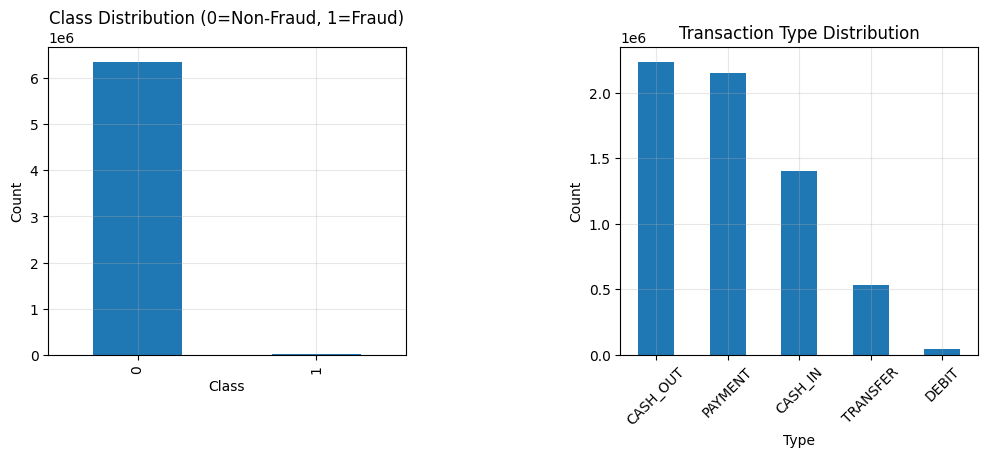

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
df["isFraud"].value_counts().plot(kind="bar", ax=ax1)
ax1.set_title("Class Distribution (0=Non-Fraud, 1=Fraud)")
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.3)


ax2 = axes[1]
df["type"].value_counts().plot(kind="bar", ax=ax2)
ax2.set_title("Transaction Type Distribution")
ax2.set_xlabel("Type")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis="x", rotation=45)


fig.subplots_adjust(wspace=0.6)

plt.show()


# **4) Preprocessing**

**4.1 Minimal preprocessing and type encoding**

In [ ]:
df = df.sort_values('step').reset_index(drop=True)

types = sorted(df["type"].unique())
type_to_id = {t: i + 1 for i, t in enumerate(types)}
df["type_id"] = df["type"].map(type_to_id).astype(np.int64)
NUM_TYPES = len(type_to_id) + 1

print("Type encoding")
print("-" * 60)
print(f"Transaction types: {types}")
print(f"Type mapping: {type_to_id}")
print(f"Total type embeddings: {NUM_TYPES} (includes padding)")


Type encoding
------------------------------------------------------------
Transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Type mapping: {'CASH_IN': 1, 'CASH_OUT': 2, 'DEBIT': 3, 'PAYMENT': 4, 'TRANSFER': 5}
Total type embeddings: 6 (includes padding)


**4.2 Train/Val/Test split by account**

In [ ]:
MAX_SEQ_LEN = 20
VAL_NEG_TARGET  = 50000
TEST_NEG_TARGET = 100000

TRAIN_MAX_WINDOWS = 200
EVAL_MAX_WINDOWS = 500

rng = np.random.default_rng(SEED)

acct = df.groupby("nameOrig", sort=False)["isFraud"].max().reset_index()
fraud_accounts_all = acct.loc[acct["isFraud"] == 1, "nameOrig"].values
normal_accounts_all = acct.loc[acct["isFraud"] == 0, "nameOrig"].values

rng.shuffle(fraud_accounts_all)
rng.shuffle(normal_accounts_all)

SAMPLE_FRAUD = min(len(fraud_accounts_all), 50000)
SAMPLE_NORMAL = min(len(normal_accounts_all), 600000)

fraud_accounts = fraud_accounts_all[:SAMPLE_FRAUD]
normal_accounts = normal_accounts_all[:SAMPLE_NORMAL]

def split_three_way(arr, train_frac=0.6, val_frac=0.2):
    n = len(arr)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    return arr[:n_train], arr[n_train:n_train+n_val], arr[n_train+n_val:]

fraud_train, fraud_val, fraud_test = split_three_way(fraud_accounts)
normal_train, normal_val, normal_test = split_three_way(normal_accounts)

normal_val = normal_val[:VAL_NEG_TARGET]
normal_test = normal_test[:TEST_NEG_TARGET]

train_accounts = np.concatenate([fraud_train, normal_train])
val_accounts = np.concatenate([fraud_val, normal_val])
test_accounts = np.concatenate([fraud_test, normal_test])

rng.shuffle(train_accounts)
rng.shuffle(val_accounts)
rng.shuffle(test_accounts)

assert set(train_accounts).isdisjoint(val_accounts)
assert set(train_accounts).isdisjoint(test_accounts)
assert set(val_accounts).isdisjoint(test_accounts)

df_train = df[df["nameOrig"].isin(train_accounts)].copy()
df_val = df[df["nameOrig"].isin(val_accounts)].copy()
df_test = df[df["nameOrig"].isin(test_accounts)].copy()

print("Split summary (account-based, no overlap)")
print("-" * 60)
print(f"Train: {len(train_accounts)} accounts, {len(df_train)} transactions")
print(f"Val:   {len(val_accounts)} accounts, {len(df_val)} transactions")
print(f"Test:  {len(test_accounts)} accounts, {len(df_test)} transactions")


Split summary (account-based, no overlap)
------------------------------------------------------------
Train: 364927 accounts, 365468 transactions
Val:   51642 accounts, 51726 transactions
Test:  101644 accounts, 101799 transactions


**4.3 Feature engineering**

In [ ]:
def engineer_features(df_subset):
    df_subset = df_subset.copy()

    df_subset["log_amount"] = np.log1p(df_subset["amount"]).astype(np.float32)

    df_subset["balance_delta_orig"] = (
        df_subset["newbalanceOrig"] - df_subset["oldbalanceOrg"]
    ).astype(np.float32)

    df_subset["balance_delta_dest"] = (
        df_subset["newbalanceDest"] - df_subset["oldbalanceDest"]
    ).astype(np.float32)

    df_subset["balance_ratio_orig"] = (
        df_subset["newbalanceOrig"] / (df_subset["oldbalanceOrg"] + 1)
    ).astype(np.float32)

    df_subset["balance_ratio_dest"] = (
        df_subset["newbalanceDest"] / (df_subset["oldbalanceDest"] + 1)
    ).astype(np.float32)

    df_subset["error_balance_orig"] = (
        df_subset["oldbalanceOrg"] - df_subset["amount"] - df_subset["newbalanceOrig"]
    ).astype(np.float32)

    df_subset["error_balance_dest"] = (
        df_subset["oldbalanceDest"] + df_subset["amount"] - df_subset["newbalanceDest"]
    ).astype(np.float32)

    return df_subset

df_train = engineer_features(df_train)
df_val = engineer_features(df_val)
df_test = engineer_features(df_test)

print("Feature engineering completed (train/val/test).")


Feature engineering completed (train/val/test).


**4.4 Build sequences**

In [ ]:
NUMERIC_FEATURES = [
    "log_amount",
    "balance_delta_orig",
    "balance_delta_dest",
    "balance_ratio_orig",
    "balance_ratio_dest",
    "error_balance_orig",
    "error_balance_dest",
]
NUM_NUMERIC_FEATURES = len(NUMERIC_FEATURES)


numeric_scaler = StandardScaler().fit(df_train[NUMERIC_FEATURES].values.astype(np.float32))

train_gaps = []
for _, g in df_train.groupby("nameOrig", sort=False):
    g = g.sort_values("step")
    gap = g["step"].diff().fillna(0).values
    gap = np.clip(gap, 0, 168)
    train_gaps.append(np.log1p(gap).astype(np.float32))

train_gaps = np.concatenate(train_gaps).reshape(-1, 1)
timegap_scaler = StandardScaler().fit(train_gaps)

print("Scalers fit on raw df_train (no window duplication)")

def build_sequences(df_subset, max_len=20, max_windows_per_account=None):
    sequences = []

    for _, group in df_subset.groupby("nameOrig", sort=False):
        group = group.sort_values("step").reset_index(drop=True)

        full_gap = group["step"].diff().fillna(0).values
        full_gap = np.clip(full_gap, 0, 168)
        full_time_gaps = np.log1p(full_gap).astype(np.float32)

        windows = []
        for i in range(len(group)):
            start = max(0, i - max_len + 1)
            seq = group.iloc[start:i+1]

            windows.append({
                "type_ids": seq["type_id"].values.astype(np.int64),
                "numeric": seq[NUMERIC_FEATURES].values.astype(np.float32),
                "time_gaps": full_time_gaps[start:i+1],
                "label": int(group.loc[i, "isFraud"]),
                "length": len(seq)
            })


        if max_windows_per_account is not None and len(windows) > max_windows_per_account:
            fraud_windows  = [w for w in windows if w["label"] == 1]
            normal_windows = [w for w in windows if w["label"] == 0]

            if len(fraud_windows) >= max_windows_per_account:
                windows = fraud_windows[:max_windows_per_account]
            else:
                remaining = max_windows_per_account - len(fraud_windows)
                windows = fraud_windows + normal_windows[-remaining:]

        sequences.extend(windows)

    return sequences

train_seqs = build_sequences(df_train, MAX_SEQ_LEN, TRAIN_MAX_WINDOWS)
val_seqs = build_sequences(df_val, MAX_SEQ_LEN, EVAL_MAX_WINDOWS)
test_seqs = build_sequences(df_test, MAX_SEQ_LEN, EVAL_MAX_WINDOWS)

assert 0 < sum(s["label"] for s in train_seqs) < len(train_seqs)
assert 0 < sum(s["label"] for s in val_seqs) < len(val_seqs)
assert 0 < sum(s["label"] for s in test_seqs) < len(test_seqs)

print("Sequence datasets built")
print("-" * 60)
print(f"Train sequences: {len(train_seqs)} (fraud: {sum(s['label'] for s in train_seqs)})")
print(f"Val sequences:   {len(val_seqs)} (fraud: {sum(s['label'] for s in val_seqs)})")
print(f"Test sequences:  {len(test_seqs)} (fraud: {sum(s['label'] for s in test_seqs)})")


Scalers fit on raw df_train (no window duplication)
Sequence datasets built
------------------------------------------------------------
Train sequences: 365468 (fraud: 4927)
Val sequences:   51726 (fraud: 1642)
Test sequences:  101799 (fraud: 1644)


**4.5 Normalization (train-only stats)**

In [ ]:
def normalize_sequences(sequences):
    for seq in sequences:
        seq['numeric'] = numeric_scaler.transform(seq['numeric']).astype(np.float32)
        seq['time_gaps'] = timegap_scaler.transform(
            seq['time_gaps'].reshape(-1, 1)
        ).flatten().astype(np.float32)

normalize_sequences(train_seqs)
normalize_sequences(val_seqs)
normalize_sequences(test_seqs)

print("Normalization applied using train-only statistics.")


Normalization applied using train-only statistics.


**4.6 Dataset & DataLoaders**

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        type_ids = torch.tensor(seq["type_ids"], dtype=torch.long)
        numeric = torch.tensor(seq["numeric"], dtype=torch.float32)
        time_gaps = torch.tensor(seq["time_gaps"], dtype=torch.float32).unsqueeze(1)
        label = torch.tensor(float(seq["label"]), dtype=torch.float32)
        length = int(seq["length"])
        return type_ids, numeric, time_gaps, label, length

def collate_sequences(batch):
    type_ids, numeric, time_gaps, labels, lengths = zip(*batch)

    type_ids_padded = pad_sequence(type_ids, batch_first=True, padding_value=0)
    numeric_padded = pad_sequence(numeric, batch_first=True, padding_value=0.0)
    time_gaps_padded = pad_sequence(time_gaps, batch_first=True, padding_value=0.0)

    labels = torch.stack(labels).float()
    lengths = torch.tensor(lengths, dtype=torch.long)

    return type_ids_padded, numeric_padded, time_gaps_padded, labels, lengths

BATCH_SIZE = 64

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    SequenceDataset(train_seqs),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
    num_workers=0,
    generator=g
)

val_loader = DataLoader(
    SequenceDataset(val_seqs),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
    num_workers=0
)

test_loader = DataLoader(
    SequenceDataset(test_seqs),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
    num_workers=0
)

print("DataLoaders ready")
print("-" * 60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


DataLoaders ready
------------------------------------------------------------
Batch size: 64
Train batches: 5711
Val batches: 809
Test batches: 1591


# **5) Model Definition**

In [ ]:
class GRUFraudDetector(nn.Module):
    def __init__(self, num_types, embed_dim=8, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()

        self.type_embedding = nn.Embedding(
            num_embeddings=num_types,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        input_size = embed_dim + NUM_NUMERIC_FEATURES + 1

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, type_ids, numeric, time_gaps, lengths):
        type_embeds = self.type_embedding(type_ids)
        x = torch.cat([type_embeds, numeric, time_gaps], dim=2)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)

        last_hidden = self.dropout(hidden[-1])
        logits = self.fc(last_hidden).squeeze(1)
        return logits


class LSTMFraudDetector(nn.Module):
    def __init__(self, num_types, embed_dim=8, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()

        self.type_embedding = nn.Embedding(
            num_embeddings=num_types,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        input_size = embed_dim + NUM_NUMERIC_FEATURES + 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, type_ids, numeric, time_gaps, lengths):
        type_embeds = self.type_embedding(type_ids)
        x = torch.cat([type_embeds, numeric, time_gaps], dim=2)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, cell) = self.lstm(packed)

        last_hidden = self.dropout(hidden[-1])
        logits = self.fc(last_hidden).squeeze(1)
        return logits


class AttentionLSTMFraudDetector(nn.Module):
    def __init__(self, num_types, embed_dim=8, hidden_size=64,
                 num_layers=2, dropout=0.3, attention_dim=64):
        super().__init__()

        self.type_embedding = nn.Embedding(
            num_embeddings=num_types,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        input_size = embed_dim + NUM_NUMERIC_FEATURES + 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.attention_W = nn.Linear(hidden_size, attention_dim, bias=True)
        self.attention_v = nn.Linear(attention_dim, 1, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, type_ids, numeric, time_gaps, lengths, return_attention=False):
        type_embeds = self.type_embedding(type_ids)
        x = torch.cat([type_embeds, numeric, time_gaps], dim=2)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)

        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        batch_size, max_len, hidden_dim = lstm_out.shape
        lengths_dev = lengths.to(lstm_out.device)

        mask = torch.arange(max_len, device=lstm_out.device).unsqueeze(0) < lengths_dev.unsqueeze(1)

        scores = self.attention_v(torch.tanh(self.attention_W(lstm_out))).squeeze(-1)
        scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = torch.softmax(scores, dim=1)
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)
        context = self.dropout(context)

        logits = self.fc(context).squeeze(1)

        if return_attention:
            return logits, attn_weights
        return logits




# **6) Training/Fine-tuning**

In [ ]:
def get_class_weight(sequences):
    fraud_count = sum(s["label"] for s in sequences)
    total_count = len(sequences)
    non_fraud_count = total_count - fraud_count
    if fraud_count == 0:
        raise RuntimeError("No fraud samples in sequences")
    pos_weight = non_fraud_count / fraud_count
    return torch.tensor([pos_weight], dtype=torch.float32, device=device)

@torch.no_grad()
def collect_predictions(model, data_loader):
    model.eval()
    all_probs, all_labels = [], []

    for type_ids, numeric, time_gaps, labels, lengths in data_loader:
        type_ids = type_ids.to(device)
        numeric  = numeric.to(device)
        time_gaps = time_gaps.to(device)

        logits = model(type_ids, numeric, time_gaps, lengths)
        probs  = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu().numpy().ravel())
        all_labels.append(labels.numpy().ravel())

    all_probs  = np.concatenate(all_probs).astype(float)
    all_labels = np.concatenate(all_labels).astype(int)
    return all_probs, all_labels

def find_threshold_at_fpr(y_true, y_prob, target_fpr=0.001):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    neg_scores = y_prob[y_true == 0]
    pos_scores = y_prob[y_true == 1]

    n_neg = len(neg_scores)
    if n_neg == 0 or len(pos_scores) == 0:
        return 1.0, 0.0, 0.0

    allowed_fp = int(np.floor(target_fpr * n_neg))
    neg_sorted = np.sort(neg_scores)[::-1]

    if allowed_fp <= 0:
        thr = np.nextafter(neg_sorted[0], np.inf)
    elif allowed_fp >= n_neg:
        thr = -np.inf
    else:
        boundary = neg_sorted[allowed_fp - 1]
        thr = np.nextafter(boundary, np.inf)

    y_pred = (y_prob >= thr).astype(int)
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    achieved_fpr = fp / n_neg
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return float(thr), float(achieved_fpr), float(recall)

def train_model(model, train_loader, val_loader, criterion, optimizer,
                max_epochs=15, patience=5, model_name="Model", target_fpr=0.001):

    best_score = -1.0
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_pr_auc": [],
        "val_roc_auc": [],
        "val_recall_at_fpr": [],
        "val_thr": [],
        "val_fpr": []
    }

    print(f"\nTraining {model_name}")
    print("-" * 60)

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for type_ids, numeric, time_gaps, labels, lengths in train_loader:
            type_ids = type_ids.to(device)
            numeric = numeric.to(device)
            time_gaps = time_gaps.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(type_ids, numeric, time_gaps, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        val_probs, val_labels = collect_predictions(model, val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_probs)
        val_pr_auc  = average_precision_score(val_labels, val_probs)

        thr, val_fpr, val_recall = find_threshold_at_fpr(val_labels, val_probs, target_fpr=target_fpr)

        history["val_roc_auc"].append(val_roc_auc)
        history["val_pr_auc"].append(val_pr_auc)
        history["val_thr"].append(thr)
        history["val_fpr"].append(val_fpr)
        history["val_recall_at_fpr"].append(val_recall)

        print(
            f"Epoch {epoch+1:2d}/{max_epochs} | Loss: {avg_loss:.4f} | "
            f"PR-AUC: {val_pr_auc:.4f} | ROC-AUC: {val_roc_auc:.4f} | "
            f"Recall@FPR={target_fpr}: {val_recall:.4f} (FPR={val_fpr:.6f})",
            end=""
        )

        if np.isfinite(val_recall) and val_recall > best_score:
            best_score = val_recall
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(" (best)")
        else:
            patience_counter += 1
            print()
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Best Val Recall@FPR={target_fpr}: {best_score:.4f}")
    return best_state, history, best_score


# **7) Evaluation**

In [ ]:
def evaluate_model(model, val_loader, test_loader, model_name="Model"):
    print(f"\nEvaluating {model_name}")
    print("-" * 60)

    val_probs, val_labels = collect_predictions(model, val_loader)
    threshold, val_fpr, val_recall = find_threshold_at_fpr(val_labels, val_probs, target_fpr=0.001)

    print(f"Threshold (from validation): {threshold:.6f}")
    print(f"Val FPR: {val_fpr:.6f} | Val Recall: {val_recall:.4f}")

    test_probs, test_labels = collect_predictions(model, test_loader)
    test_roc_auc = roc_auc_score(test_labels, test_probs)
    test_pr_auc = average_precision_score(test_labels, test_probs)

    test_preds = (test_probs >= threshold).astype(int)
    cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    test_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    print("Test Results")
    print(f"ROC-AUC: {test_roc_auc:.4f} | PR-AUC: {test_pr_auc:.4f}")
    print(f"Recall: {test_recall:.4f} | FPR: {test_fpr:.6f} | Precision: {test_precision:.4f}")
    print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")

    return {
        "threshold": threshold,
        "test_roc_auc": test_roc_auc,
        "test_pr_auc": test_pr_auc,
        "test_recall": test_recall,
        "test_fpr": test_fpr,
        "test_precision": test_precision,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }


# **8) Comparison & Analysis**

**8.1 Run variations**

In [16]:

pos_weight = get_class_weight(train_seqs)
print(f"Positive class weight (pos_weight): {pos_weight.item():.2f}")

# Variation 1: GRU
reseed_everything(SEED)
gru_model = GRUFraudDetector(num_types=NUM_TYPES, embed_dim=8, hidden_size=64, num_layers=2, dropout=0.3).to(device)
gru_params = sum(p.numel() for p in gru_model.parameters())
gru_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

gru_best_state, gru_history, gru_best_val_recall = train_model(
    gru_model, train_loader, val_loader, gru_criterion, gru_optimizer,
    max_epochs=15, patience=5, model_name="GRU", target_fpr=0.001
)
gru_model.load_state_dict(gru_best_state)
gru_results = evaluate_model(gru_model, val_loader, test_loader, model_name="GRU")
gru_results.update({"model": "GRU", "params": gru_params, "best_val_recall_at_fpr": float(gru_best_val_recall)})

# Variation 2: LSTM
reseed_everything(SEED)
lstm_model = LSTMFraudDetector(num_types=NUM_TYPES, embed_dim=8, hidden_size=64, num_layers=2, dropout=0.3).to(device)
lstm_params = sum(p.numel() for p in lstm_model.parameters())
lstm_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

lstm_best_state, lstm_history, lstm_best_val_recall = train_model(
    lstm_model, train_loader, val_loader, lstm_criterion, lstm_optimizer,
    max_epochs=15, patience=5, model_name="LSTM", target_fpr=0.001
)
lstm_model.load_state_dict(lstm_best_state)
lstm_results = evaluate_model(lstm_model, val_loader, test_loader, model_name="LSTM")
lstm_results.update({"model": "LSTM", "params": lstm_params, "best_val_recall_at_fpr": float(lstm_best_val_recall)})

# Variation 3: Attention-LSTM
reseed_everything(SEED)
attn_model = AttentionLSTMFraudDetector(num_types=NUM_TYPES, embed_dim=8, hidden_size=64, num_layers=2, dropout=0.3, attention_dim=64).to(device)
attn_params = sum(p.numel() for p in attn_model.parameters())
attn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
attn_optimizer = optim.Adam(attn_model.parameters(), lr=0.001)

attn_best_state, attn_history, attn_best_val_recall = train_model(
    attn_model, train_loader, val_loader, attn_criterion, attn_optimizer,
    max_epochs=15, patience=5, model_name="Attention-LSTM", target_fpr=0.001
)
attn_model.load_state_dict(attn_best_state)
attn_results = evaluate_model(attn_model, val_loader, test_loader, model_name="Attention-LSTM")
attn_results.update({"model": "Attention-LSTM", "params": attn_params, "best_val_recall_at_fpr": float(attn_best_val_recall)})


Positive class weight (pos_weight): 73.18

Training GRU
------------------------------------------------------------
Epoch  1/15 | Loss: 0.3056 | PR-AUC: 0.8879 | ROC-AUC: 0.9928 | Recall@FPR=0.001: 0.6273 (FPR=0.000978) (best)
Epoch  2/15 | Loss: 0.2423 | PR-AUC: 0.9076 | ROC-AUC: 0.9941 | Recall@FPR=0.001: 0.6778 (FPR=0.000978) (best)
Epoch  3/15 | Loss: 0.2250 | PR-AUC: 0.9141 | ROC-AUC: 0.9945 | Recall@FPR=0.001: 0.6979 (FPR=0.000978) (best)
Epoch  4/15 | Loss: 0.2090 | PR-AUC: 0.9206 | ROC-AUC: 0.9948 | Recall@FPR=0.001: 0.7266 (FPR=0.000978) (best)
Epoch  5/15 | Loss: 0.2005 | PR-AUC: 0.9208 | ROC-AUC: 0.9946 | Recall@FPR=0.001: 0.7661 (FPR=0.000978) (best)
Epoch  6/15 | Loss: 0.1914 | PR-AUC: 0.9248 | ROC-AUC: 0.9949 | Recall@FPR=0.001: 0.7789 (FPR=0.000978) (best)
Epoch  7/15 | Loss: 0.1871 | PR-AUC: 0.9240 | ROC-AUC: 0.9950 | Recall@FPR=0.001: 0.7527 (FPR=0.000978)
Epoch  8/15 | Loss: 0.1821 | PR-AUC: 0.9276 | ROC-AUC: 0.9951 | Recall@FPR=0.001: 0.7686 (FPR=0.000978)
Epoch  9/

**8.2 Metrics comparison table**

In [17]:
comparison_df = pd.DataFrame([
    {
        "Model": gru_results["model"],
        "Parameters": f"{gru_results['params']:,}",
        "Best Val Recall@FPR": f"{gru_results['best_val_recall_at_fpr']:.4f}",
        "Test PR-AUC": f"{gru_results['test_pr_auc']:.4f}",
        "Test ROC-AUC": f"{gru_results['test_roc_auc']:.4f}",
        "Recall@FPR=0.001": f"{gru_results['test_recall']:.4f}",
        "Test FPR": f"{gru_results['test_fpr']:.6f}",
        "Precision": f"{gru_results['test_precision']:.4f}",
        "TP": gru_results['tp'],
        "FP": gru_results['fp'],
        "TN": gru_results['tn'],
        "FN": gru_results['fn'],
        "Threshold": f"{gru_results['threshold']:.6f}",
    },
    {
        "Model": lstm_results["model"],
        "Parameters": f"{lstm_results['params']:,}",
        "Best Val Recall@FPR": f"{lstm_results['best_val_recall_at_fpr']:.4f}",
        "Test PR-AUC": f"{lstm_results['test_pr_auc']:.4f}",
        "Test ROC-AUC": f"{lstm_results['test_roc_auc']:.4f}",
        "Recall@FPR=0.001": f"{lstm_results['test_recall']:.4f}",
        "Test FPR": f"{lstm_results['test_fpr']:.6f}",
        "Precision": f"{lstm_results['test_precision']:.4f}",
        "TP": lstm_results['tp'],
        "FP": lstm_results['fp'],
        "TN": lstm_results['tn'],
        "FN": lstm_results['fn'],
        "Threshold": f"{lstm_results['threshold']:.6f}",
    },
    {
        "Model": attn_results["model"],
        "Parameters": f"{attn_results['params']:,}",
        "Best Val Recall@FPR": f"{attn_results['best_val_recall_at_fpr']:.4f}",
        "Test PR-AUC": f"{attn_results['test_pr_auc']:.4f}",
        "Test ROC-AUC": f"{attn_results['test_roc_auc']:.4f}",
        "Recall@FPR=0.001": f"{attn_results['test_recall']:.4f}",
        "Test FPR": f"{attn_results['test_fpr']:.6f}",
        "Precision": f"{attn_results['test_precision']:.4f}",
        "TP": attn_results['tp'],
        "FP": attn_results['fp'],
        "TN": attn_results['tn'],
        "FN": attn_results['fn'],
        "Threshold": f"{attn_results['threshold']:.6f}",
    }
])

comparison_df


,Model,Parameters,Best Val Recall@FPR,Test PR-AUC,Test ROC-AUC,Recall@FPR=0.001,Test FPR,Precision,TP,FP,TN,FN,Threshold
0,GRU,"40,817",0.7789,0.8853,0.9955,0.7634,0.001078,0.9208,1255,108,100047,389,0.970347
1,LSTM,"54,385",0.7704,0.8885,0.9958,0.7500,0.000919,0.9306,1233,92,100063,411,0.963715
2,Attention-LSTM,"58,609",0.7759,0.8846,0.9954,0.7573,0.001028,0.9236,1245,103,100052,399,0.952632


**8.3 Visualizations**

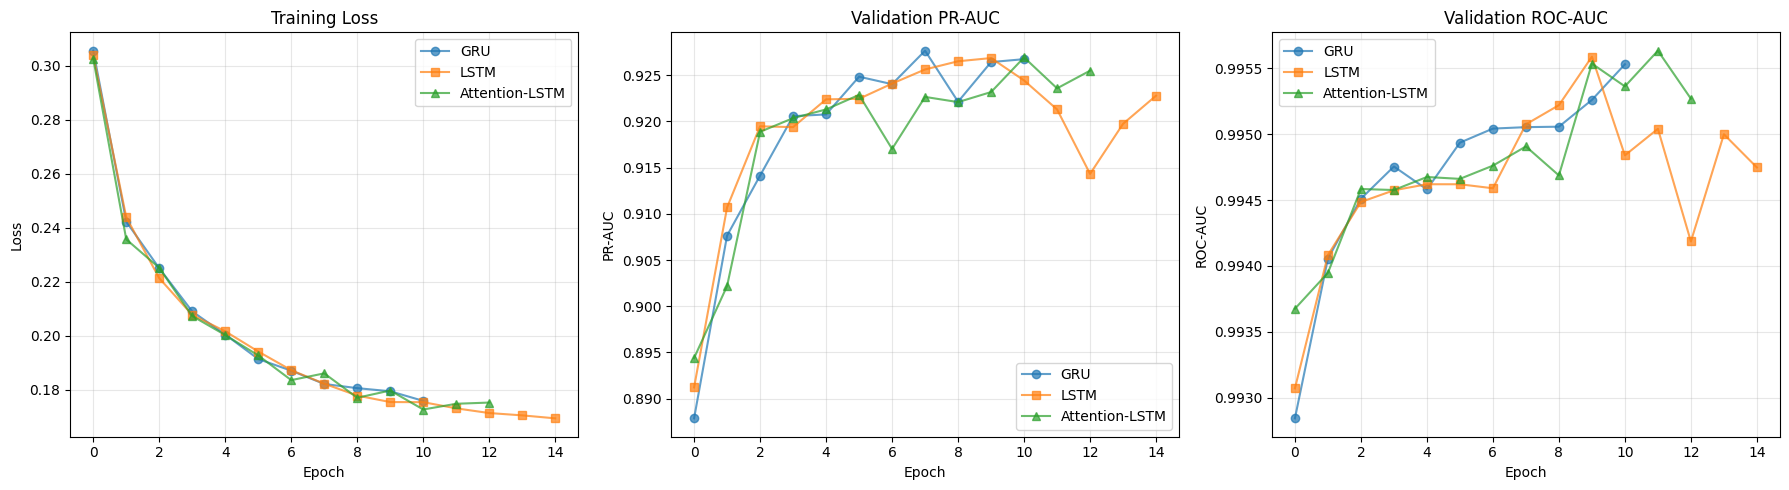

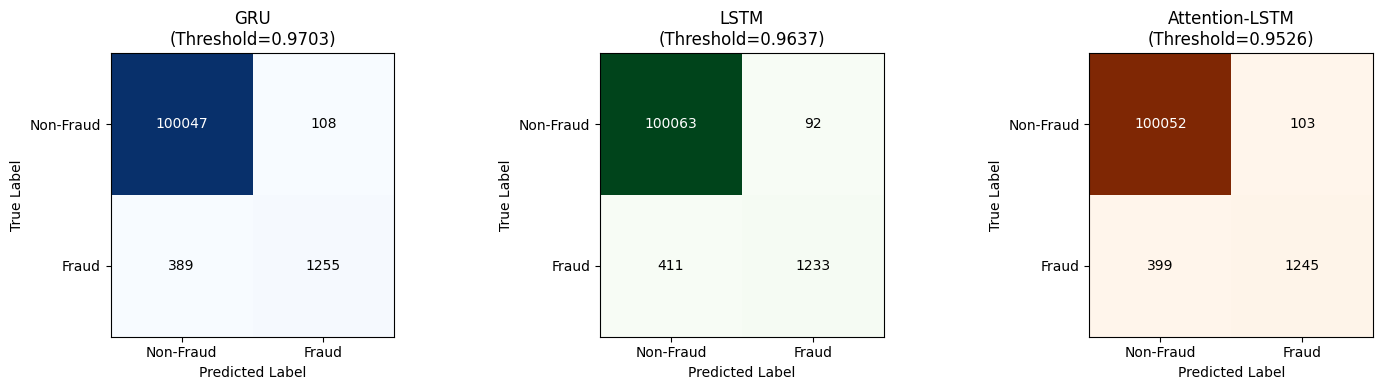

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(gru_history['train_loss'], marker='o', label='GRU', alpha=0.7)
axes[0].plot(lstm_history['train_loss'], marker='s', label='LSTM', alpha=0.7)
axes[0].plot(attn_history['train_loss'], marker='^', label='Attention-LSTM', alpha=0.7)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gru_history['val_pr_auc'], marker='o', label='GRU', alpha=0.7)
axes[1].plot(lstm_history['val_pr_auc'], marker='s', label='LSTM', alpha=0.7)
axes[1].plot(attn_history['val_pr_auc'], marker='^', label='Attention-LSTM', alpha=0.7)
axes[1].set_title('Validation PR-AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(gru_history['val_roc_auc'], marker='o', label='GRU', alpha=0.7)
axes[2].plot(lstm_history['val_roc_auc'], marker='s', label='LSTM', alpha=0.7)
axes[2].plot(attn_history['val_roc_auc'], marker='^', label='Attention-LSTM', alpha=0.7)
axes[2].set_title('Validation ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('ROC-AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = [
    ("GRU", gru_results, 'Blues'),
    ("LSTM", lstm_results, 'Greens'),
    ("Attention-LSTM", attn_results, 'Oranges')
]

for idx, (name, results, cmap) in enumerate(models_data):
    cm = np.array([[results['tn'], results['fp']],
                   [results['fn'], results['tp']]])

    axes[idx].imshow(cm, interpolation='nearest', cmap=cmap)
    axes[idx].set_title(f'{name}\n(Threshold={results["threshold"]:.4f})')

    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                           ha="center", va="center",
                           color="white" if cm[i, j] > thresh else "black")

    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[idx].set_yticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()


**8.4 Final prints**

In [19]:
print("Final Results (raw dict outputs)")
print("-" * 60)

print("GRU Results:")
for key, val in gru_results.items():
    print(f"  {key}: {val}")

print("\nLSTM Results:")
for key, val in lstm_results.items():
    print(f"  {key}: {val}")

print("\nAttention-LSTM Results:")
for key, val in attn_results.items():
    print(f"  {key}: {val}")


Final Results (raw dict outputs)
------------------------------------------------------------
GRU Results:
  threshold: 0.9703473448753358
  test_roc_auc: 0.9955391102428705
  test_pr_auc: 0.8852797693763372
  test_recall: 0.76338199513382
  test_fpr: 0.0010783285906844392
  test_precision: 0.9207630227439472
  tp: 1255
  fp: 108
  tn: 100047
  fn: 389
  model: GRU
  params: 40817
  best_val_recall_at_fpr: 0.7789281364190013

LSTM Results:
  threshold: 0.9637151956558229
  test_roc_auc: 0.9958081761590702
  test_pr_auc: 0.8885259247388995
  test_recall: 0.75
  test_fpr: 0.0009185762068793371
  test_precision: 0.930566037735849
  tp: 1233
  fp: 92
  tn: 100063
  fn: 411
  model: LSTM
  params: 54385
  best_val_recall_at_fpr: 0.7704019488428745

Attention-LSTM Results:
  threshold: 0.9526324272155763
  test_roc_auc: 0.995391638094773
  test_pr_auc: 0.8845563540177945
  test_recall: 0.7572992700729927
  test_fpr: 0.0010284059707453448
  test_precision: 0.9235905044510386
  tp: 1245
  fp: 

**8.5 Save outputs**

In [20]:
SAVE_DIR = "/content/drive/MyDrive/ALP_Task2_Results"
os.makedirs(SAVE_DIR, exist_ok=True)


torch.save(gru_best_state, os.path.join(SAVE_DIR, "gru_best_state.pt"))
torch.save(lstm_best_state, os.path.join(SAVE_DIR, "lstm_best_state.pt"))
torch.save(attn_best_state, os.path.join(SAVE_DIR, "attn_best_state.pt"))

comparison_df.to_csv(os.path.join(SAVE_DIR, "task2_comparison.csv"), index=False)
pd.DataFrame(gru_history).to_csv(os.path.join(SAVE_DIR, "gru_history.csv"), index=False)
pd.DataFrame(lstm_history).to_csv(os.path.join(SAVE_DIR, "lstm_history.csv"), index=False)
pd.DataFrame(attn_history).to_csv(os.path.join(SAVE_DIR, "attn_history.csv"), index=False)

print(f"Saved results to: {SAVE_DIR}")


Saved results to: /content/drive/MyDrive/ALP_Task2_Results


# **9) Discussion**

**Discussion**

- Best model under strict FPR (Recall@FPR≈0.001): GRU performs best for our main objective, achieving the highest test recall (0.7634) while keeping test FPR close to the target (0.00108). It also has the smallest model size (40,817 parameters), making it a strong MVP choice.

- PR-AUC ranking (from test_pr_auc): LSTM (0.8885) > GRU (0.8853) > Attention-LSTM (0.8846). This shows LSTM ranks fraud risk slightly better overall, but GRU is better for maximizing recall under the strict FPR constraint.

**Limitations**
- PaySim is synthetic, so results may differ from real bank transaction streams.

- This notebook evaluates sequence models only; late fusion with tabular models will be added in the hybrid stage.

- Strict FPR makes evaluation sensitive to thresholding; we fixed the threshold using validation only to avoid test leakage.

**MVP Implication**
The best-performing sequence model here becomes the sequence module candidate for later fusion with the tabular branch.


# **10) References**

Dataset:
- PaySim (Kaggle): https://www.kaggle.com/datasets/ealaxi/paysim1

Papers:
- Benchaji et al. (2021): https://link.springer.com/article/10.1186/s40537-021-00541-8  
- Tian (2025): https://aemps.ewapub.com/article/view/23993  
- Btoush et al. (2025): https://www.mdpi.com/2076-3417/15/3/1081  
- Chagahi et al. (2025): https://ideas.repec.org/p/arx/papers/2410.09069.html  
